# Regression like transfer function- Linear Model

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.datamining.pca import PCA
from utils.funcs_linear import fit_plot_linear_model, plot_pcs

## Predictor- Load large scale atmospheric variables
### mean sea level pressure, spatial gradient of mean sea level pressure

In [17]:
global_sst = xr.open_dataset(
    "https://geoocean.sci.unican.es/thredds/dodsC/geoocean/global-sst"
)
global_sst["time"] = np.char.decode(global_sst.time.values, encoding="utf-8").astype(
    "datetime64"  # Convert to datetime64 for time operations
)
global_sst = global_sst.sel(time=slice("1973", "1984")).load()
global_sst

<xarray.Dataset> Size: 150MB
Dimensions:    (time: 144, latitude: 361, longitude: 720)
Coordinates:
  * latitude   (latitude) float32 1kB 89.88 89.38 88.88 ... -89.12 -89.62 -90.0
  * time       (time) datetime64[s] 1kB 1973-01-01 1973-02-01 ... 1984-12-01
  * longitude  (longitude) float32 3kB 0.125 0.625 1.125 ... 358.6 359.1 359.6
Data variables:
    sst        (time, latitude, longitude) float32 150MB -1.692 -1.692 ... nan

## Predictor- define indices/covariates/input layers
### PCA- Principal Component Analysis + reduce dimensionality

In [18]:
pca = PCA(n_components=3)

pcs = pca.fit_transform(
    data=global_sst,
    vars_to_stack=["sst"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)
pcs

2025-10-09 19:05:39,908 - PCA - WARNING - Using 175082 out of 259920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 3kB
Dimensions:      (time: 144, n_component: 3)
Coordinates:
  * time         (time) datetime64[s] 1kB 1973-01-01 1973-02-01 ... 1984-12-01
  * n_component  (n_component) int64 24B 0 1 2
Data variables:
    PCs          (time, n_component) float32 2kB -351.8 -31.31 ... -49.41 -95.72
    stds         (n_component) float32 12B 331.1 122.2 105.3

### PCA- spatial modes EOF

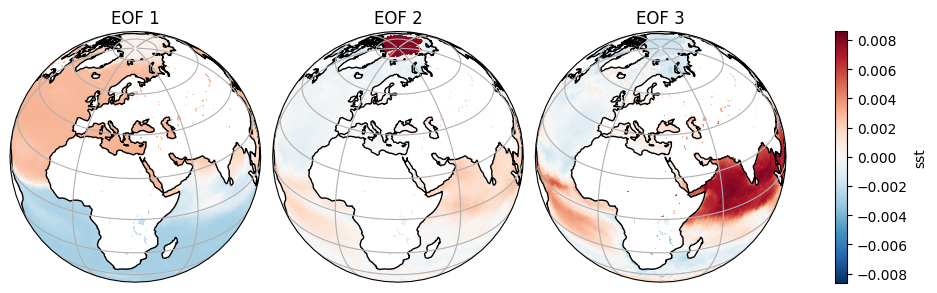

In [19]:
pca.plot_eofs(num_eofs=3, vars_to_plot=["sst"], map_center=(30, 30))

### PCA- temporal indices PCs

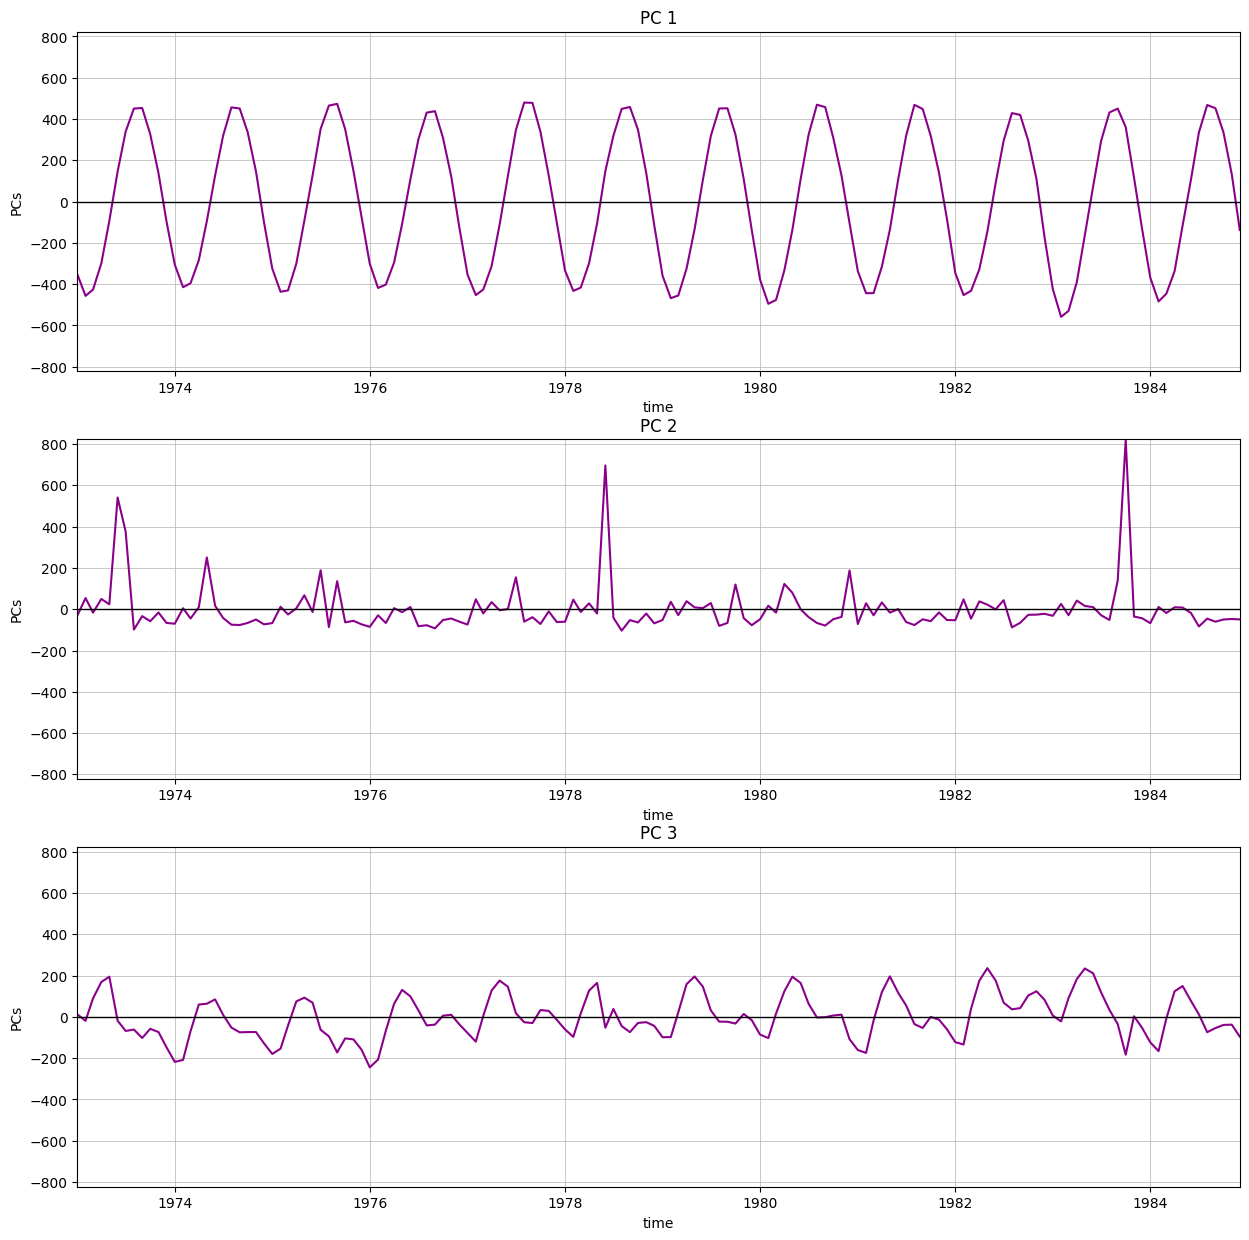

In [20]:
n_pcs = 3
plot_pcs(pca, n_pcs)

## Predictand- Load regional/local wave data
### significant wave height, peak period

In [21]:
river_dicharge = pd.read_csv(
    "inputs/river_discharge/processed_station.csv", index_col=0
)
river_dicharge.index = pd.to_datetime(river_dicharge.index)
river_dicharge

,POINTID,YEAR,MONTH,DISCHRG
1973-01-01,1167.0,1973.0,1.0,1336.0
1973-02-01,1167.0,1973.0,2.0,1450.0
1973-03-01,1167.0,1973.0,3.0,1609.0
1973-04-01,1167.0,1973.0,4.0,1523.0
1973-05-01,1167.0,1973.0,5.0,1922.0
...,...,...,...,...
1984-08-01,1167.0,1984.0,8.0,2350.0
1984-09-01,1167.0,1984.0,9.0,1840.0
1984-10-01,1167.0,1984.0,10.0,1725.0
1984-11-01,1167.0,1984.0,11.0,1493.0


<Axes: title={'center': 'n_component = 0'}, xlabel='time', ylabel='PCs'>

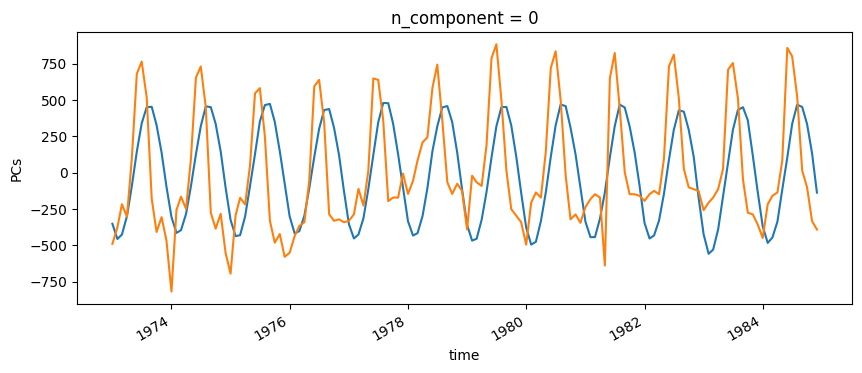

In [ ]:
pcs.isel(n_component=0).PCs.plot(figsize=(10, 4))
(river_dicharge.DISCHRG - river_dicharge.DISCHRG.mean()).plot()

## Predictand to Predictor - Model
### Multiple Linear Regression
X - temporal indices PCs- Predictor: regressors, exogenous variables, explanatory variables, covariates, input variables, predictor variables, or independent variables

Y - wave parameter- Predictand: regressand, endogenous variable, response variable, target variable, measured variable, criterion variable, or dependent variable

In [24]:
pca.pcs

<xarray.Dataset> Size: 3kB
Dimensions:      (time: 144, n_component: 3)
Coordinates:
  * time         (time) datetime64[s] 1kB 1973-01-01 1973-02-01 ... 1984-12-01
  * n_component  (n_component) int64 24B 0 1 2
Data variables:
    PCs          (time, n_component) float32 2kB -351.8 -31.31 ... -49.41 -95.72
    stds         (n_component) float32 12B 331.1 122.2 105.3

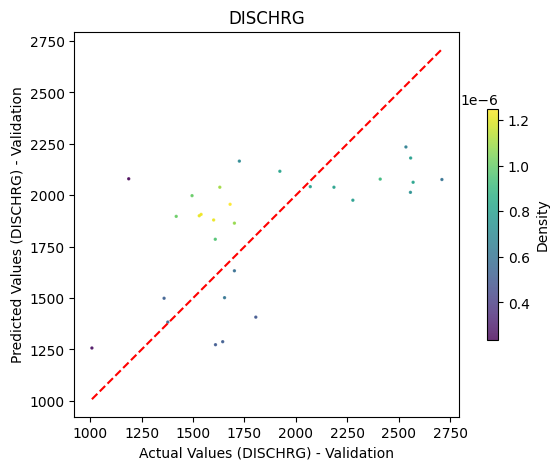

In [ ]:
n_pcs = pca.pca.n_components_  # This is the number of PCs to use as X

common_times = np.intersect1d(pca.pcs.time, river_dicharge.index)

X = pca.pcs.sel(time=common_times).PCs.values
Ys = river_dicharge.loc[common_times, ["DISCHRG"]].values

fit_plot_linear_model(X, Ys, keys=["DISCHRG"], perc_train=0.8)